# Last.fm bench

Compare embedding recommendations against Last.fm results.

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

## Data Prep

In [2]:
DATA_DIR = Path("../datasets")
BENCH_PATH = DATA_DIR / "lastfm_recommendations_all_top_listener.csv"
RECS_PATH = DATA_DIR / "recommendations_album_level_avg_embeddings.parquet"
CATALOG_PATH = DATA_DIR / "albums.csv"

# Number of top recommendations to keep for each query album
TOP_N = 4

In [3]:
def _top_n_subset(df, top_n):
    """Keep ranks 1..top_n and drop query albums with fewer than top_n recs."""
    sub = df[df["rank"] <= top_n].copy()
    keys = ["query_artist", "query_album"]
    n_recs = sub.groupby(keys, observed=True)["rank"].transform("count")
    return sub[n_recs >= top_n].reset_index(drop=True)


def keep_top_n(df, top_n=TOP_N, verbose=True):
    keys = ["query_artist", "query_album"]
    n_queries_before = df[df["rank"] <= top_n].groupby(keys, observed=True).ngroups
    out = _top_n_subset(df, top_n)
    if verbose:
        n_queries_after = out.groupby(keys, observed=True).ngroups
        print(f"Kept {n_queries_after:,} / {n_queries_before:,} query albums with >={top_n} recs")
    return out


def _norm_str(s) -> str:
    """Same normalization as ingestion/albums.ipynb (quotes, accents, whitespace)."""
    s = str(s).strip().lower()
    for ch in ("\u2019", "\u2018", "\u201b", "\u2032", "`", "\u00b4"):
        s = s.replace(ch, "'")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s)


def _norm(s: pd.Series) -> pd.Series:
    return s.fillna("").map(_norm_str)


def query_key(df):
    """Normalized artist::album key for query albums."""
    return _norm(df["query_artist"]) + "::" + _norm(df["query_album"])


def rec_key(df):
    """Normalized artist::album key for recommended albums."""
    return _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"])


def metric_row(metric, recommender=None, **values):
    """One metrics row for pd.DataFrame append/concat."""
    row = {"metric": metric, **values}
    if recommender is not None:
        row["recommender"] = recommender
    return row


In [4]:
# Load the album catalog from the CSV file containing metadata for all albums reviewed in the dataset
catalog = pd.read_csv(CATALOG_PATH)
catalog["key"] = _norm(catalog["artist"]) + "::" + _norm(catalog["album"])
catalog_reviews = catalog.set_index("key")["review_count"]
catalog_ids = catalog.set_index("key")["album_id"]
print(f"Catalog: {len(catalog):,} albums")

Catalog: 30,516 albums


### Recommendations

Load and sanitize recommendations from our recommender.


In [5]:
recs = pd.read_parquet(RECS_PATH)
recs = recs.drop(columns=["rec_length_flag"])

### Last.fm Bench

Load and sanitize recommendations from Last.fm benchmark recommender.

In [6]:
df = pd.read_csv(BENCH_PATH)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["rank"] = pd.to_numeric(df["rank"], errors="coerce")

# keep successful recommendations only
df = df[df["status"] == "ok"].reset_index(drop=True)

n_albums = df["album_id"].nunique()
print(f"File: {BENCH_PATH.name}")
print(f"Strategy: {df['strategy'].iloc[0]}  |  Albums: {n_albums:,}  |  Rec rows: {len(df):,}")
df.head(5)

File: lastfm_recommendations_all_top_listener.csv
Strategy: top_listener  |  Albums: 2,124  |  Rec rows: 8,776


,album_id,artist,album,review_count,strategy,status,error,seed_track,seed_listeners,rec_artist,rec_album,score,rank,rec_listeners,seed_tags,rec_tags
0,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Bruce Cockburn,Guitar Gods Vol. 3 (Live),0.317808,1.0,8.0,NaN,NaN
1,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Cowboy Junkies,200 More Miles,0.238679,2.0,2696.0,NaN,NaN
2,10960,Indigo Girls,Poseidon and the Bitter Bug,1,top_listener,ok,NaN,Sugar Tongue,10042.0,Tracy Chapman,Live & Alive,0.216455,3.0,275.0,NaN,NaN
3,10811,Ida,Lovers Prayers,1,top_listener,ok,NaN,Lovers Prayers,16583.0,The Secret Stars,The Secret Stars,1.000000,1.0,2380.0,NaN,NaN
4,10811,Ida,Lovers Prayers,1,top_listener,ok,NaN,Lovers Prayers,16583.0,The American Analog Set,Know by Heart,0.993583,2.0,292488.0,NaN,NaN


In [7]:
baseline = df.rename(columns={
    "artist": "query_artist",
    "album":  "query_album",
}).reindex(columns=[
    "album_id", "query_artist", "query_album", "rec_artist", "rec_album",
    "score", "rank", "seed_listeners", "rec_listeners",
]).copy()


baseline_n = keep_top_n(baseline)
baseline_1 = keep_top_n(baseline, 1)

Kept 1,666 / 2,124 query albums with >=4 recs
Kept 2,124 / 2,124 query albums with >=1 recs


In [8]:
baseline_n.head(6)

,album_id,query_artist,query_album,rec_artist,rec_album,score,rank,seed_listeners,rec_listeners
0,10811,Ida,Lovers Prayers,The Secret Stars,The Secret Stars,1.000000,1.0,16583.0,2380.0
1,10811,Ida,Lovers Prayers,The American Analog Set,Know by Heart,0.993583,2.0,16583.0,292488.0
2,10811,Ida,Lovers Prayers,Cat Power,You Are Free,0.799562,3.0,16583.0,591532.0
3,10811,Ida,Lovers Prayers,Someone Still Loves You Boris Yeltsin,Broom,0.790617,4.0,16583.0,337203.0
4,5817,David Axelrod,David Axelrod,Marc Copland,Time Within Time,1.000000,1.0,7165.0,147.0
5,5817,David Axelrod,David Axelrod,DJ Okawari,Kaleidoscope,0.999960,2.0,7165.0,47065.0


In [9]:
baseline_1.head(6)

,album_id,query_artist,query_album,rec_artist,rec_album,score,rank,seed_listeners,rec_listeners
0,10960,Indigo Girls,Poseidon and the Bitter Bug,Bruce Cockburn,Guitar Gods Vol. 3 (Live),0.317808,1.0,10042.0,8.0
1,10811,Ida,Lovers Prayers,The Secret Stars,The Secret Stars,1.000000,1.0,16583.0,2380.0
2,5817,David Axelrod,David Axelrod,Marc Copland,Time Within Time,1.000000,1.0,7165.0,147.0
3,1682,Augie March,Strange Bird,Paul Kelly,Paul Kelly's Greatest Hits: Songs From The Sou...,0.826532,1.0,23212.0,31522.0
4,30023,Xiu Xiu,Plays the Music of Twin Peaks,Swans,Soundtracks for the Blind,0.103711,1.0,112067.0,226461.0
5,14217,Lil Durk,300 Days 300 Nights,Only The Family,Rememberance (feat. Lil Durk),0.581710,1.0,33155.0,92.0


### Match to baseline queries

Keep only embedding recs whose query album appears in the Last.fm baseline (normalized artist::album match). If the embedding corpus has duplicate spellings of the same album (e.g. curly vs straight apostrophes), keep one variant per normalized key so query counts align with the baseline.

In [10]:
baseline_query_keys = set(query_key(baseline))

def filter_to_baseline(df):
    out = df.loc[query_key(df).isin(baseline_query_keys)].copy()
    out["_query_key"] = query_key(out)

    canonical = (
        out.groupby("_query_key", observed=True)[["query_artist", "query_album"]]
        .first()
        .rename(columns={"query_artist": "_canon_artist", "query_album": "_canon_album"})
    )
    out = out.join(canonical, on="_query_key")
    out = out[
        (out["query_artist"] == out["_canon_artist"])
        & (out["query_album"] == out["_canon_album"])
    ].drop(columns=["_query_key", "_canon_artist", "_canon_album"]).reset_index(drop=True)

    n_queries = out.groupby(["query_artist", "query_album"], observed=True).ngroups
    print(f"{len(out):,} rows, {n_queries:,} queries")
    return out

print("Embedding recs (matched to baseline):")
recs_matched = filter_to_baseline(recs)
recs_1 = keep_top_n(recs_matched, 1)
recs_n = keep_top_n(recs_matched)

Embedding recs (matched to baseline):
21,240 rows, 2,124 queries
Kept 2,124 / 2,124 query albums with >=1 recs
Kept 2,124 / 2,124 query albums with >=4 recs


# Comparisons

Each recommender has two views: `*_1` (rank-1 only — top-pick metrics) and `*_n` (full top-N lists — list-level metrics). Embedding recs are restricted to query albums present in the Last.fm baseline.


## Repetition

Do different query albums get steered toward the same recommended **albums** and **artists**? We sweep list depth `n = 1 … TOP_N`: at each `n`, keep ranks `1..n` (only queries with at least `n` recs), then measure how concentrated recommendations are.

The embedding model draws from a **much smaller catalog** than Last.fm’s open index, so some extra repetition is expected. The comparison below tracks how close we get to the baseline, with emphasis on **n = 1** (top pick) and **n = TOP_N** (full list).

### Albums

At each `n`:

- **Unique share** — fraction of rec slots that point to distinct album titles (higher = more diverse).
- **Repeated hubs** — count of distinct albums recommended as a top pick for *more than one* query album. Each hub is a target the recommender keeps returning across unrelated queries; a high count means many queries get steered toward the same albums.

In [11]:
def repeated_stats(df, rec_col):
    counts = df[rec_col].str.strip().str.lower().value_counts()
    n_total = len(df)
    n_unique = counts.size
    n_repeated = int((counts > 1).sum())
    return {
        "n_total": n_total,
        "n_queries": df.groupby(["query_artist", "query_album"], observed=True).ngroups,
        "n_unique": n_unique,
        "n_repeated": n_repeated,
        "unique_share": n_unique / n_total if n_total else float("nan"),
        "repeated_share": n_repeated / n_unique if n_unique else float("nan"),
    }


def _top_n_subset(df, top_n):
    """Keep ranks 1..top_n; quiet helper (also defined in Data Prep)."""
    sub = df[df["rank"] <= top_n].copy()
    keys = ["query_artist", "query_album"]
    n_recs = sub.groupby(keys, observed=True)["rank"].transform("count")
    return sub[n_recs >= top_n].reset_index(drop=True)


def repeated_sweep(recs_df, baseline_df, rec_col, metric, top_n=TOP_N):
    rows = []
    for n in range(1, top_n + 1):
        for label, source in [("embedding recs", recs_df), ("last.fm baseline", baseline_df)]:
            sub = _top_n_subset(source, n)
            stats = repeated_stats(sub, rec_col)
            rows.append({"metric": metric, "n": n, "recommender": label, **stats})
    return pd.DataFrame(rows)


repeated_sweep_albums = repeated_sweep(recs_matched, baseline, "rec_album", "repeated_albums")
repeated_sweep_albums

,metric,n,recommender,n_total,n_queries,n_unique,n_repeated,unique_share,repeated_share
0,repeated_albums,1,embedding recs,2124,2124,1752,243,0.824859,0.138699
1,repeated_albums,1,last.fm baseline,2124,2124,1993,112,0.938324,0.056197
2,repeated_albums,2,embedding recs,4248,2124,3160,632,0.743879,0.200000
3,repeated_albums,2,last.fm baseline,4222,2111,3834,311,0.908100,0.081116
4,repeated_albums,3,embedding recs,6372,2124,4372,1068,0.686127,0.244282
5,repeated_albums,3,last.fm baseline,6057,2019,5350,532,0.883276,0.099439
6,repeated_albums,4,embedding recs,8496,2124,5413,1527,0.637123,0.282099
7,repeated_albums,4,last.fm baseline,6664,1666,5759,658,0.864196,0.114256


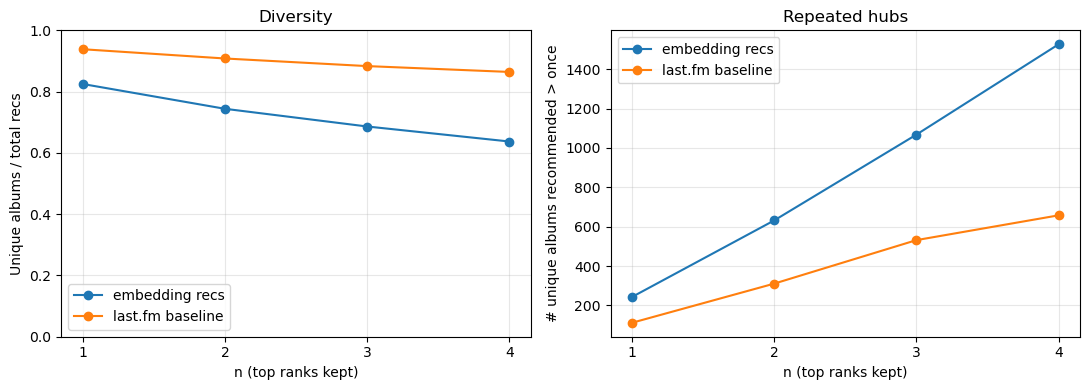

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [
    ("embedding recs", "C0"),
    ("last.fm baseline", "C1"),
]:
    sub = repeated_sweep_albums[repeated_sweep_albums["recommender"] == label]
    axes[0].plot(sub["n"], sub["unique_share"], marker="o", label=label, color=color)
    axes[1].plot(sub["n"], sub["n_repeated"], marker="o", label=label, color=color)

axes[0].set(xlabel="n (top ranks kept)", ylabel="Unique albums / total recs", title="Diversity")
axes[0].set_xticks(range(1, TOP_N + 1))
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set(xlabel="n (top ranks kept)", ylabel="# unique albums recommended > once", title="Repeated hubs")
axes[1].set_xticks(range(1, TOP_N + 1))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Artists

Same sweep on recommended **artist** names. Artist-level hub counts are often higher than album-level because one act can appear on many different albums.


In [13]:
repeated_sweep_artists = repeated_sweep(recs_matched, baseline, "rec_artist", "repeated_artists")
repeated_sweep_artists

,metric,n,recommender,n_total,n_queries,n_unique,n_repeated,unique_share,repeated_share
0,repeated_artists,1,embedding recs,2124,2124,1539,320,0.724576,0.207927
1,repeated_artists,1,last.fm baseline,2124,2124,1795,244,0.845104,0.135933
2,repeated_artists,2,embedding recs,4248,2124,2500,821,0.588512,0.328400
3,repeated_artists,2,last.fm baseline,4222,2111,3025,767,0.716485,0.253554
4,repeated_artists,3,embedding recs,6372,2124,3234,1248,0.507533,0.385900
5,repeated_artists,3,last.fm baseline,6057,2019,3966,1195,0.654780,0.301311
6,repeated_artists,4,embedding recs,8496,2124,3842,1637,0.452213,0.426080
7,repeated_artists,4,last.fm baseline,6664,1666,4153,1354,0.623199,0.326029


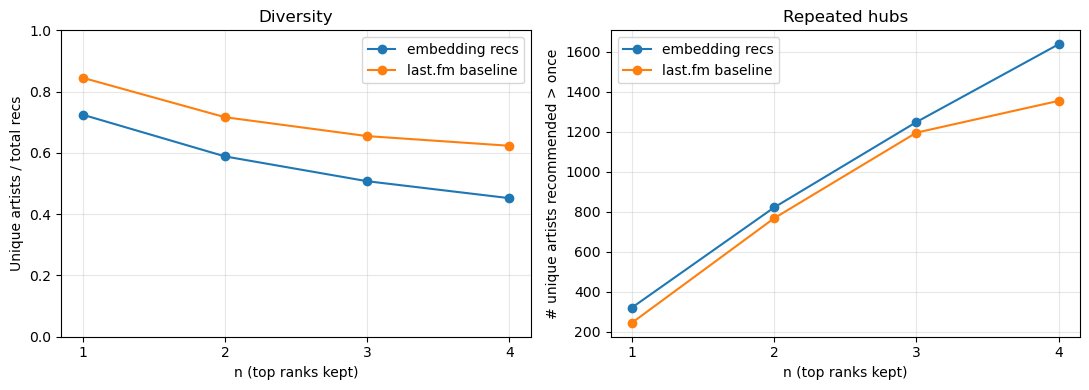

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [
    ("embedding recs", "C0"),
    ("last.fm baseline", "C1"),
]:
    sub = repeated_sweep_artists[repeated_sweep_artists["recommender"] == label]
    axes[0].plot(sub["n"], sub["unique_share"], marker="o", label=label, color=color)
    axes[1].plot(sub["n"], sub["n_repeated"], marker="o", label=label, color=color)

axes[0].set(xlabel="n (top ranks kept)", ylabel="Unique artists / total recs", title="Diversity")
axes[0].set_xticks(range(1, TOP_N + 1))
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set(xlabel="n (top ranks kept)", ylabel="# unique artists recommended > once", title="Repeated hubs")
axes[1].set_xticks(range(1, TOP_N + 1))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Summary

Key comparison at **n = 1** (single top pick) and **n = TOP_N** (full list).

**Hub metrics** count how many distinct albums or artists are recommended to multiple query albums. Unlike unique share (a slot-level average), hubs measure *how many targets* act as shared funnel points — e.g. 200 hubs means 200 different albums each appear on at least two unrelated query lists. **Hub ratio (emb/base)** compares that count across models; values above 1× mean the embedding recommender recycles more shared targets than Last.fm.

In [15]:
REPETITION_KEY_NS = [1, TOP_N]

repetition_key = pd.concat([
    repeated_sweep_albums[repeated_sweep_albums["n"].isin(REPETITION_KEY_NS)],
    repeated_sweep_artists[repeated_sweep_artists["n"].isin(REPETITION_KEY_NS)],
], ignore_index=True)

summary_cols = ["metric", "n", "recommender", "n_queries", "unique_share", "n_repeated"]
repetition_key = repetition_key[summary_cols].sort_values(["metric", "n", "recommender"])
repetition_key


,metric,n,recommender,n_queries,unique_share,n_repeated
0,repeated_albums,1,embedding recs,2124,0.824859,243
1,repeated_albums,1,last.fm baseline,2124,0.938324,112
2,repeated_albums,4,embedding recs,2124,0.637123,1527
3,repeated_albums,4,last.fm baseline,1666,0.864196,658
4,repeated_artists,1,embedding recs,2124,0.724576,320
5,repeated_artists,1,last.fm baseline,2124,0.845104,244
6,repeated_artists,4,embedding recs,2124,0.452213,1637
7,repeated_artists,4,last.fm baseline,1666,0.623199,1354


In [16]:
# ratios — embedding vs baseline (positive Δ = embedding trails / repeats more)

EMB, BASE = "embedding recs", "last.fm baseline"


def _repetition_row(df, n, recommender):
    return df[(df["n"] == n) & (df["recommender"] == recommender)].iloc[0]


rows = []
for scope, df in [("Albums", repeated_sweep_albums), ("Artists", repeated_sweep_artists)]:
    for n in REPETITION_KEY_NS:
        e, b = _repetition_row(df, n, EMB), _repetition_row(df, n, BASE)
        rows.append(
            {
                "scope": scope,
                "n": n,
                "unique_share_emb": e["unique_share"],
                "unique_share_base": b["unique_share"],
                "delta_unique_pp": (b["unique_share"] - e["unique_share"]) * 100,
                "repeated_hubs_emb": int(e["n_repeated"]),
                "repeated_hubs_base": int(b["n_repeated"]),
                "delta_repeated_hubs": int(e["n_repeated"] - b["n_repeated"]),
                "hub_ratio_emb_over_base": e["n_repeated"] / b["n_repeated"] if b["n_repeated"] else float("nan"),
            }
        )

repetition_ratios = pd.DataFrame(rows)
repetition_ratios["unique_share_emb"] = repetition_ratios["unique_share_emb"].map(lambda x: f"{100 * x:.1f}%")
repetition_ratios["unique_share_base"] = repetition_ratios["unique_share_base"].map(lambda x: f"{100 * x:.1f}%")
repetition_ratios["delta_unique_pp"] = repetition_ratios["delta_unique_pp"].map(lambda x: f"{x:+.1f}")
repetition_ratios["delta_repeated_hubs"] = repetition_ratios["delta_repeated_hubs"].map(lambda x: f"{x:+,.0f}")
repetition_ratios["hub_ratio_emb_over_base"] = repetition_ratios["hub_ratio_emb_over_base"].map(
    lambda x: f"{x:.2f}x" if pd.notna(x) else ""
)

repetition_ratios.rename(
    columns={
        "scope": "Scope",
        "n": "n",
        "unique_share_emb": "Unique (emb)",
        "unique_share_base": "Unique (base)",
        "delta_unique_pp": "Δ unique (pp)",
        "repeated_hubs_emb": "Hubs (emb)",
        "repeated_hubs_base": "Hubs (base)",
        "delta_repeated_hubs": "Δ hubs (emb − base)",
        "hub_ratio_emb_over_base": "Hub ratio (emb/base)",
    },
    inplace=True,
)

repetition_ratios


,Scope,n,Unique (emb),Unique (base),Δ unique (pp),Hubs (emb),Hubs (base),Δ hubs (emb − base),Hub ratio (emb/base)
0,Albums,1,82.5%,93.8%,+11.3,243,112,+131,2.17x
1,Albums,4,63.7%,86.4%,+22.7,1527,658,+869,2.32x
2,Artists,1,72.5%,84.5%,+12.1,320,244,+76,1.31x
3,Artists,4,45.2%,62.3%,+17.1,1637,1354,+283,1.21x


In [17]:
def _pct(x):
    return f"{100 * x:.1f}%"


def _repetition_writeup(albums_df, artists_df, ns=(1, TOP_N)):
    emb, base = "embedding recs", "last.fm baseline"

    for n in ns:
        n_label = "top pick" if n == 1 else f"full top-{n} lists"
        ae, ab = _repetition_row(albums_df, n, emb), _repetition_row(albums_df, n, base)
        te, tb = _repetition_row(artists_df, n, emb), _repetition_row(artists_df, n, base)

        album_gap = (ab["unique_share"] - ae["unique_share"]) * 100
        artist_gap = (tb["unique_share"] - te["unique_share"]) * 100

        print(
            f"**n = {n} ({n_label}).**\n"
            f"Album diversity: embedding {_pct(ae['unique_share'])} unique vs baseline {_pct(ab['unique_share'])} "
            f"({album_gap:.0f} pp gap; {int(ae['n_repeated']):,} vs {int(ab['n_repeated']):,} repeated hub albums).\n"
            f"Artist diversity: {_pct(te['unique_share'])} vs {_pct(tb['unique_share'])} "
            f"({artist_gap:.0f} pp gap; {int(te['n_repeated']):,} vs {int(tb['n_repeated']):,} repeated hub artists).\n"
        )


_repetition_writeup(repeated_sweep_albums, repeated_sweep_artists)


**n = 1 (top pick).**
Album diversity: embedding 82.5% unique vs baseline 93.8% (11 pp gap; 243 vs 112 repeated hub albums).
Artist diversity: 72.5% vs 84.5% (12 pp gap; 320 vs 244 repeated hub artists).

**n = 4 (full top-4 lists).**
Album diversity: embedding 63.7% unique vs baseline 86.4% (23 pp gap; 1,527 vs 658 repeated hub albums).
Artist diversity: 45.2% vs 62.3% (17 pp gap; 1,637 vs 1,354 repeated hub artists).



#### Takeaways

**What this means.** The embedding recommender indexes a much smaller album pool than Last.fm, so trailing the baseline on diversity is expected. At **n = 1**, the gap is moderate: the model's single best pick is already reasonably spread out, but still produces more repeated hub albums than the baseline.

The gap **widens at n = TOP_N**. As list depth grows, the embedding model recycles the same albums and especially the same artists across unrelated queries. That pattern is stronger than catalog size alone would explain for a single top pick — it suggests rank-2…TOP_N slots are funneling into a narrow set of targets.

**Goal:** treat Last.fm as the diversity ceiling and shrink these gaps over time — first on top picks (n = 1), then on full lists (n = TOP_N), where artist repetition is the bigger concern.

*Δ unique (pp) = baseline − embedding unique share. **Δ hubs** = embedding − baseline repeated-hub count (positive = more shared funnel targets). **Hub ratio** = embedding hub count ÷ baseline hub count.*

## Variety

How spread out is each query's top-N list? **Repetition** (above) measures whether different queries hit the same targets globally; **variety** measures diversity *within* a single query's list.

- **Variety ratio** = distinct rec targets ÷ list length (1.0 = every slot is a different album or artist).
- **All distinct** = share of queries whose full list has no repeats.
- **Single-target only** = share of queries where every rec is the same album or artist.

### Albums

Distinct recommended **albums** (artist::album key) within each query's top-N list.

In [18]:
def list_variety_stats(df, kind):
    """Distinct rec targets within each query's recommendation list."""
    keys = ["query_artist", "query_album"]
    if kind == "album":
        target = rec_key(df)
    else:
        target = _norm(df["rec_artist"])

    stats = pd.DataFrame({"target": target, "n_recs": 1}).join(df[keys])
    stats = stats.groupby(keys, observed=True).agg(
        n_recs=("n_recs", "sum"),
        n_unique=("target", "nunique"),
    )
    stats["ratio"] = stats["n_unique"] / stats["n_recs"]
    return {
        "n_queries": len(stats),
        "mean_unique": stats["n_unique"].mean(),
        "mean_variety_ratio": stats["ratio"].mean(),
        "all_distinct_share": (stats["n_unique"] == stats["n_recs"]).mean(),
        "single_target_share": (stats["n_unique"] == 1).mean(),
    }


def _print_variety(row, label, top_n=TOP_N):
    print(f"[{row['recommender']}]")
    print(f"  Queries:              {row['n_queries']:,.0f}")
    print(f"  Mean unique {label}:  {row['mean_unique']:.2f} / {top_n}")
    print(f"  Mean variety ratio:   {row['mean_variety_ratio']:.1%}")
    print(f"  All distinct:         {row['all_distinct_share']:.1%}")
    print(f"  Single {label} only:  {row['single_target_share']:.1%}")
    print()


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
album_variety = pd.DataFrame(
    [metric_row("album_variety", label, **list_variety_stats(df, "album")) for label, df in sources]
)

for _, row in album_variety.iterrows():
    _print_variety(row, "albums")

album_variety

[embedding recs]
  Queries:              2,124
  Mean unique albums:  4.00 / 4
  Mean variety ratio:   99.9%
  All distinct:         99.7%
  Single albums only:  0.0%

[last.fm baseline]
  Queries:              1,666
  Mean unique albums:  4.00 / 4
  Mean variety ratio:   100.0%
  All distinct:         100.0%
  Single albums only:  0.0%



,metric,n_queries,mean_unique,mean_variety_ratio,all_distinct_share,single_target_share,recommender
0,album_variety,2124,3.996704,0.999176,0.996704,0.0,embedding recs
1,album_variety,1666,4.000000,1.000000,1.000000,0.0,last.fm baseline


### Artists

Distinct recommended **artists** within each query's top-N list. Variety is often lower here because one act can fill multiple album slots.

In [19]:
artist_variety = pd.DataFrame(
    [metric_row("artist_variety", label, **list_variety_stats(df, "artist")) for label, df in sources]
)

for _, row in artist_variety.iterrows():
    _print_variety(row, "artists")

artist_variety

[embedding recs]
  Queries:              2,124
  Mean unique artists:  3.55 / 4
  Mean variety ratio:   88.7%
  All distinct:         68.9%
  Single artists only:  2.9%

[last.fm baseline]
  Queries:              1,666
  Mean unique artists:  3.52 / 4
  Mean variety ratio:   88.1%
  All distinct:         56.3%
  Single artists only:  0.1%



,metric,n_queries,mean_unique,mean_variety_ratio,all_distinct_share,single_target_share,recommender
0,artist_variety,2124,3.549435,0.887359,0.689266,0.028719,embedding recs
1,artist_variety,1666,3.524610,0.881152,0.563025,0.000600,last.fm baseline


### Summary

Side-by-side comparison on full top-N lists. Positive **Δ variety (pp)** means the embedding lists are *less* spread out than Last.fm.

In [20]:
EMB, BASE = "embedding recs", "last.fm baseline"


def _variety_row(df, recommender):
    return df[df["recommender"] == recommender].iloc[0]


rows = []
for scope, df, label in [
    ("Albums", album_variety, "albums"),
    ("Artists", artist_variety, "artists"),
]:
    e, b = _variety_row(df, EMB), _variety_row(df, BASE)
    rows.append(
        {
            "scope": scope,
            "mean_unique_emb": e["mean_unique"],
            "mean_unique_base": b["mean_unique"],
            "delta_mean_unique": e["mean_unique"] - b["mean_unique"],
            "variety_emb": e["mean_variety_ratio"],
            "variety_base": b["mean_variety_ratio"],
            "delta_variety_pp": (e["mean_variety_ratio"] - b["mean_variety_ratio"]) * 100,
            "all_distinct_emb": e["all_distinct_share"],
            "all_distinct_base": b["all_distinct_share"],
            "delta_all_distinct_pp": (e["all_distinct_share"] - b["all_distinct_share"]) * 100,
            "single_target_emb": e["single_target_share"],
            "single_target_base": b["single_target_share"],
            "delta_single_target_pp": (e["single_target_share"] - b["single_target_share"]) * 100,
        }
    )

variety_summary = pd.DataFrame(rows)
variety_summary["mean_unique_emb"] = variety_summary["mean_unique_emb"].map(lambda x: f"{x:.2f}")
variety_summary["mean_unique_base"] = variety_summary["mean_unique_base"].map(lambda x: f"{x:.2f}")
variety_summary["delta_mean_unique"] = variety_summary["delta_mean_unique"].map(lambda x: f"{x:+.2f}")
for col in ["variety_emb", "variety_base", "all_distinct_emb", "all_distinct_base", "single_target_emb", "single_target_base"]:
    variety_summary[col] = variety_summary[col].map(lambda x: f"{100 * x:.1f}%")
for col in ["delta_variety_pp", "delta_all_distinct_pp", "delta_single_target_pp"]:
    variety_summary[col] = variety_summary[col].map(lambda x: f"{x:+.1f}")

variety_summary.rename(
    columns={
        "scope": "Scope",
        "mean_unique_emb": "Mean unique (emb)",
        "mean_unique_base": "Mean unique (base)",
        "delta_mean_unique": "Δ mean unique",
        "variety_emb": "Variety ratio (emb)",
        "variety_base": "Variety ratio (base)",
        "delta_variety_pp": "Δ variety (pp)",
        "all_distinct_emb": "All distinct (emb)",
        "all_distinct_base": "All distinct (base)",
        "delta_all_distinct_pp": "Δ all distinct (pp)",
        "single_target_emb": "Single-target (emb)",
        "single_target_base": "Single-target (base)",
        "delta_single_target_pp": "Δ single-target (pp)",
    },
    inplace=True,
)

variety_summary

,Scope,Mean unique (emb),Mean unique (base),Δ mean unique,Variety ratio (emb),Variety ratio (base),Δ variety (pp),All distinct (emb),All distinct (base),Δ all distinct (pp),Single-target (emb),Single-target (base),Δ single-target (pp)
0,Albums,4.00,4.00,-0.00,99.9%,100.0%,-0.1,99.7%,100.0%,-0.3,0.0%,0.0%,+0.0
1,Artists,3.55,3.52,+0.02,88.7%,88.1%,+0.6,68.9%,56.3%,+12.6,2.9%,0.1%,+2.8


## Score distribution

Shape of rank-1 similarity scores. Note the scales differ: embedding cosine similarity vs Last.fm track-match score — compare shapes, not absolute values.

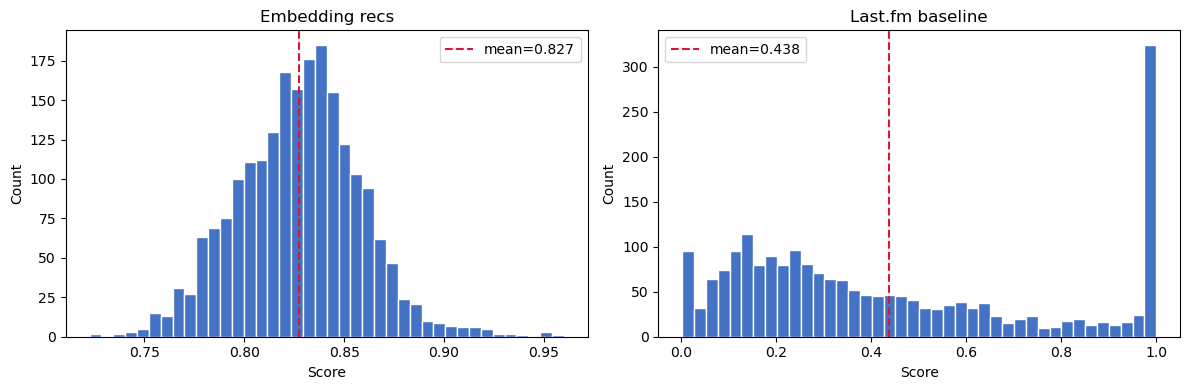

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, s, label in zip(
    axes,
    [recs_1["score"], baseline_1["score"]],
    ["Embedding recs", "Last.fm baseline"],
):
    ax.hist(s.dropna(), bins=40, color="#4472C4", edgecolor="white")
    ax.axvline(s.mean(), color="crimson", ls="--", label=f"mean={s.mean():.3f}")
    ax.set(title=label, xlabel="Score", ylabel="Count")
    ax.legend()
plt.tight_layout()
plt.show()

## Reciprocity

If artist A recommends artist B, does B recommend A back?

Each recommendation is a directed **edge**; a reciprocal pair `(A→B, B→A)` means the two nodes point at each other. High reciprocity suggests **closed neighborhoods** — recommendations stay inside a tight cluster instead of opening outward. We measure this at **artist** level and **album** level (artist::album pairs).

### Albums

Album-to-album edges use normalized `query_artist::query_album → rec_artist::rec_album`. **Reciprocal rate** = share of edges whose reverse partner also appears in the graph.

In [22]:
def reciprocity_stats(edges):
    reciprocal = sum(1 for a, b in edges if (b, a) in edges)
    n_edges = len(edges)
    return {
        "n_edges": n_edges,
        "n_reciprocal": reciprocal,
        "reciprocal_rate": reciprocal / n_edges if n_edges else float("nan"),
    }


def album_reciprocity_stats(df):
    """If album A recommends album B, does B recommend A back?"""
    edges = set(zip(
        _norm(df["query_artist"]) + "::" + _norm(df["query_album"]),
        _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"]),
    ))
    return reciprocity_stats(edges)


def _print_reciprocity(row):
    print(f"[{row['recommender']}]")
    print(f"  Edges:       {row['n_edges']:,.0f}")
    print(f"  Reciprocal:  {row['n_reciprocal']:,.0f}")
    print(f"  Rate:        {row['reciprocal_rate']:.1%}")
    print()


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
album_reciprocity = pd.DataFrame(
    [metric_row("album_reciprocity", label, **album_reciprocity_stats(df)) for label, df in sources]
)

for _, row in album_reciprocity.iterrows():
    _print_reciprocity(row)

album_reciprocity

[embedding recs]
  Edges:       8,489
  Reciprocal:  180
  Rate:        2.1%

[last.fm baseline]
  Edges:       6,664
  Reciprocal:  32
  Rate:        0.5%



,metric,n_edges,n_reciprocal,reciprocal_rate,recommender
0,album_reciprocity,8489,180,0.021204,embedding recs
1,album_reciprocity,6664,32,0.004802,last.fm baseline


### Artists

Artist-to-artist edges collapse each side to the query/recommended **artist** name. Reciprocity is usually higher here than at album level — one act's albums can create mutual links even when the exact album pair does not reverse.

In [23]:
def artist_reciprocity_stats(df):
    """If artist A recommends artist B, does B recommend A back?"""
    edges = set(zip(_norm(df["query_artist"]), _norm(df["rec_artist"])))
    return reciprocity_stats(edges)


artist_reciprocity = pd.DataFrame(
    [metric_row("artist_reciprocity", label, **artist_reciprocity_stats(df)) for label, df in sources]
)

for _, row in artist_reciprocity.iterrows():
    _print_reciprocity(row)

artist_reciprocity

[embedding recs]
  Edges:       7,217
  Reciprocal:  259
  Rate:        3.6%

[last.fm baseline]
  Edges:       5,653
  Reciprocal:  159
  Rate:        2.8%



,metric,n_edges,n_reciprocal,reciprocal_rate,recommender
0,artist_reciprocity,7217,259,0.035887,embedding recs
1,artist_reciprocity,5653,159,0.028127,last.fm baseline


### Summary

Side-by-side comparison on full top-N lists. Positive **Δ rate (pp)** means the embedding graph is *more* mutually closed than Last.fm.

In [24]:
from IPython.display import Markdown, display

EMB, BASE = "embedding recs", "last.fm baseline"


def _reciprocity_row(df, recommender):
    return df[df["recommender"] == recommender].iloc[0]


def _pct(x):
    return f"{100 * x:.1f}%"


rows = []
for scope, df in [("Albums", album_reciprocity), ("Artists", artist_reciprocity)]:
    e, b = _reciprocity_row(df, EMB), _reciprocity_row(df, BASE)
    delta_pp = (e["reciprocal_rate"] - b["reciprocal_rate"]) * 100
    rows.append(
        {
            "scope": scope,
            "rate_emb": e["reciprocal_rate"],
            "rate_base": b["reciprocal_rate"],
            "delta_rate_pp": delta_pp,
            "reciprocal_emb": int(e["n_reciprocal"]),
            "reciprocal_base": int(b["n_reciprocal"]),
            "edges_emb": int(e["n_edges"]),
            "edges_base": int(b["n_edges"]),
        }
    )

reciprocity_summary = pd.DataFrame(rows)
reciprocity_summary["rate_emb"] = reciprocity_summary["rate_emb"].map(_pct)
reciprocity_summary["rate_base"] = reciprocity_summary["rate_base"].map(_pct)
reciprocity_summary["delta_rate_pp"] = reciprocity_summary["delta_rate_pp"].map(lambda x: f"{x:+.1f}")
reciprocity_summary.rename(
    columns={
        "scope": "Scope",
        "rate_emb": "Reciprocal rate (emb)",
        "rate_base": "Reciprocal rate (base)",
        "delta_rate_pp": "Δ rate (pp)",
        "reciprocal_emb": "Reciprocal pairs (emb)",
        "reciprocal_base": "Reciprocal pairs (base)",
        "edges_emb": "Edges (emb)",
        "edges_base": "Edges (base)",
    },
    inplace=True,
)

reciprocity = pd.concat([album_reciprocity, artist_reciprocity], ignore_index=True)

ae, ab = _reciprocity_row(album_reciprocity, EMB), _reciprocity_row(album_reciprocity, BASE)
te, tb = _reciprocity_row(artist_reciprocity, EMB), _reciprocity_row(artist_reciprocity, BASE)
album_delta = (ae["reciprocal_rate"] - ab["reciprocal_rate"]) * 100
artist_delta = (te["reciprocal_rate"] - tb["reciprocal_rate"]) * 100

reciprocity_summary

writeup = f"""#### Takeaways

**Albums:** reciprocal rate is low for both recommenders ({_pct(ae['reciprocal_rate'])} embedding vs {_pct(ab['reciprocal_rate'])} baseline; {album_delta:+.1f} pp). Exact album↔album back-links are rare — lists rarely reverse on the same title pair.

**Artists (emphasis):** this is the more informative reciprocity signal. Rates run higher ({_pct(te['reciprocal_rate'])} vs {_pct(tb['reciprocal_rate'])}; {artist_delta:+.1f} pp) because mutual recommendations between acts are more common than exact album reversals. Embedding shows **{int(te['n_reciprocal']):,}** reciprocal artist pairs vs **{int(tb['n_reciprocal']):,}** on the baseline ({te['reciprocal_rate'] / tb['reciprocal_rate']:.1f}× the reciprocal rate).

**What this means.** Artist-level reciprocity captures whether the recommender builds **mutual artist neighborhoods** — query act X points to act Y and Y points back. That pattern is stronger than album-level closure and is where embedding vs Last.fm differences show up most clearly. When improving the model, artist reciprocity is the metric to watch alongside artist repetition from the Repetition section.

*Δ rate (pp) = embedding reciprocal rate − baseline reciprocal rate (positive = embedding is more closed).*"""

display(Markdown(writeup))

#### Takeaways

**Albums:** reciprocal rate is low for both recommenders (2.1% embedding vs 0.5% baseline; +1.6 pp). Exact album↔album back-links are rare — lists rarely reverse on the same title pair.

**Artists (emphasis):** this is the more informative reciprocity signal. Rates run higher (3.6% vs 2.8%; +0.8 pp) because mutual recommendations between acts are more common than exact album reversals. Embedding shows **259** reciprocal artist pairs vs **159** on the baseline (1.3× the reciprocal rate).

**What this means.** Artist-level reciprocity captures whether the recommender builds **mutual artist neighborhoods** — query act X points to act Y and Y points back. That pattern is stronger than album-level closure and is where embedding vs Last.fm differences show up most clearly. When improving the model, artist reciprocity is the metric to watch alongside artist repetition from the Repetition section.

*Δ rate (pp) = embedding reciprocal rate − baseline reciprocal rate (positive = embedding is more closed).*

## Novelty

How uncommon are the recommended albums across query lists?

- **List reach** — avg # query lists each recommended album appears in (lower = more novel).
- **Singleton share** — share of rec slots where the album appears on only one list.
- **Normalized novelty** — self-information on a 0–1 scale (1 = unique to one list).
- **Effective catalog** — if recs were spread uniformly, how many distinct albums that would imply.

In [32]:
def _novelty_base(df):
    n_lists = df.groupby(["query_artist", "query_album"], observed=True).ngroups
    key = rec_key(df)
    reach = key.map(key.value_counts())
    return n_lists, reach

def list_reach_stats(df):
    n_lists, reach = _novelty_base(df)
    return {
        "n_lists": n_lists,
        "mean_reach": reach.mean(),
        "median_reach": reach.median(),
    }

def singleton_share_stats(df):
    _, reach = _novelty_base(df)
    return {
        "singleton_share": (reach == 1).mean(),
    }

def normalized_novelty_stats(df):
    n_lists, reach = _novelty_base(df)
    log_n = np.log2(n_lists)
    norm = np.log2(n_lists / reach) / log_n if log_n else reach * 0
    return {
        "mean_novelty": norm.mean(),
        "median_novelty": norm.median(),
    }

def effective_catalog_stats(df):
    key = rec_key(df)
    counts = key.value_counts()
    p = counts / counts.sum()
    return {
        "effective_catalog": 2 ** (-(p * np.log2(p)).sum())
    }

sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]

# Compute all metrics for each source/model
rows = []
for label, df in sources:
    row = {"recommender": label}
    row.update(list_reach_stats(df))
    row.update(singleton_share_stats(df))
    row.update(normalized_novelty_stats(df))
    row.update(effective_catalog_stats(df))
    rows.append(row)

novelty = pd.DataFrame(rows)
novelty

,recommender,n_lists,mean_reach,median_reach,singleton_share,mean_novelty,median_novelty,effective_catalog
0,embedding recs,2124,3.573211,2.0,0.471045,0.909726,0.909523,4254.617070
1,last.fm baseline,1666,1.330132,1.0,0.787665,0.974645,1.000000,5521.402282


### Summary

Side-by-side comparison on full top-N lists. Lower **reach** = more novel; higher **singleton**, **novelty**, and **effective catalog** = more novel.

In [33]:
from IPython.display import Markdown, display

EMB, BASE = "embedding recs", "last.fm baseline"
e = novelty[novelty["recommender"] == EMB].iloc[0]
b = novelty[novelty["recommender"] == BASE].iloc[0]

reach_delta = e["mean_reach"] - b["mean_reach"]
singleton_delta = (e["singleton_share"] - b["singleton_share"]) * 100
novelty_delta = (e["mean_novelty"] - b["mean_novelty"]) * 100
catalog_delta = e["effective_catalog"] - b["effective_catalog"]

novelty_summary = pd.DataFrame(
    [
        {"Metric": "List reach (mean)", "Embedding": f"{e['mean_reach']:.2f}", "Baseline": f"{b['mean_reach']:.2f}", "Δ (emb − base)": f"{reach_delta:+.2f}"},
        {"Metric": "Singleton share", "Embedding": f"{100 * e['singleton_share']:.1f}%", "Baseline": f"{100 * b['singleton_share']:.1f}%", "Δ (emb − base)": f"{singleton_delta:+.1f} pp"},
        {"Metric": "Normalized novelty (mean)", "Embedding": f"{100 * e['mean_novelty']:.1f}%", "Baseline": f"{100 * b['mean_novelty']:.1f}%", "Δ (emb − base)": f"{novelty_delta:+.1f} pp"},
        {"Metric": "Effective catalog", "Embedding": f"{e['effective_catalog']:,.0f}", "Baseline": f"{b['effective_catalog']:,.0f}", "Δ (emb − base)": f"{catalog_delta:+,.0f}"},
    ]
)

novelty_summary

writeup = f"""#### Takeaways

**All four metrics agree:** embedding is **less novel** than Last.fm. Recommended albums appear on **{e['mean_reach']:.1f}** query lists on average (vs **{b['mean_reach']:.1f}**; {reach_delta:+.1f}), and only **{100 * e['singleton_share']:.0f}%** of rec slots are singletons (vs **{100 * b['singleton_share']:.0f}%**; {singleton_delta:+.1f} pp).

**Effective catalog** is smaller too ({e['effective_catalog']:,.0f} vs {b['effective_catalog']:,.0f}; {catalog_delta:+,.0f}) — recs behave as if drawn from fewer distinct albums. Normalized novelty runs **{100 * e['mean_novelty']:.0f}%** vs **{100 * b['mean_novelty']:.0f}%** ({novelty_delta:+.1f} pp). This lines up with **Repetition**: shared hubs recycle the same albums across unrelated queries.

*Positive Δ reach = embedding recycles albums across more lists (less novel). Positive Δ on share metrics = embedding is more novel.*"""

display(Markdown(writeup))

#### Takeaways

**All four metrics agree:** embedding is **less novel** than Last.fm. Recommended albums appear on **3.6** query lists on average (vs **1.3**; +2.2), and only **47%** of rec slots are singletons (vs **79%**; -31.7 pp).

**Effective catalog** is smaller too (4,255 vs 5,521; -1,267) — recs behave as if drawn from fewer distinct albums. Normalized novelty runs **91%** vs **97%** (-6.5 pp). This lines up with **Repetition**: shared hubs recycle the same albums across unrelated queries.

*Positive Δ reach = embedding recycles albums across more lists (less novel). Positive Δ on share metrics = embedding is more novel.*

## Catalog coverage

What share of the review catalog (`albums.csv`) ever gets recommended? Low coverage plus high concentration means the recommender lives in a small popular neighborhood. Also reports how many rec slots go to the top 1% most-recommended albums.

In [26]:
def catalog_coverage_stats(df):
    """Share of catalog albums recommended at least once + rec concentration."""
    key = rec_key(df)
    in_catalog = key.isin(catalog_reviews.index)
    recommended = set(key[in_catalog])
    counts = key.value_counts()
    top1pct = max(1, int(len(counts) * 0.01))
    top_share = counts.head(top1pct).sum() / counts.sum() if len(counts) else float("nan")
    n_catalog = len(catalog)
    return {
        "rec_rows_in_catalog_share": in_catalog.mean(),
        "n_recommended_albums": len(recommended),
        "n_catalog_albums": n_catalog,
        "catalog_coverage_share": len(recommended) / n_catalog if n_catalog else float("nan"),
        "top1pct_rec_album_slot_share": top_share,
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
catalog_coverage = pd.DataFrame(
    [metric_row("catalog_coverage", label, **catalog_coverage_stats(df)) for label, df in sources]
)

for _, row in catalog_coverage.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  Rec rows in catalog:  {row['rec_rows_in_catalog_share']:.1%}")
    print(
        f"  Catalog coverage:     {row['n_recommended_albums']:,.0f} / {row['n_catalog_albums']:,.0f} albums ({row['catalog_coverage_share']:.1%})"
    )
    print(f"  Top 1% rec albums take {row['top1pct_rec_album_slot_share']:.1%} of all rec slots")
    print()

catalog_coverage

[embedding recs]
  Rec rows in catalog:  95.6%
  Catalog coverage:     5,208 / 30,516 albums (17.1%)
  Top 1% rec albums take 8.4% of all rec slots

[last.fm baseline]
  Rec rows in catalog:  31.3%
  Catalog coverage:     1,659 / 30,516 albums (5.4%)
  Top 1% rec albums take 3.6% of all rec slots



,metric,rec_rows_in_catalog_share,n_recommended_albums,n_catalog_albums,catalog_coverage_share,top1pct_rec_album_slot_share,recommender
0,catalog_coverage,0.956215,5208,30516,0.170665,0.083686,embedding recs
1,catalog_coverage,0.312725,1659,30516,0.054365,0.035864,last.fm baseline


## Popularity bias

Do recommendations skew toward popular albums? Two signals:
- **review_count** (both recommenders): mean reviews of recommended in-catalog albums vs the catalog mean; ratio > 1 = popularity bias.
- **Last.fm listeners** (baseline only, from `rec_listeners` / `seed_listeners` in the batch CSV): are recommended albums more listened-to than the seeds that produced them?

In [27]:
def popularity_bias_stats(df):
    """Mean review_count of recommended (in-catalog) albums vs the catalog mean."""
    rec_reviews = rec_key(df).map(catalog_reviews).dropna()
    catalog_mean = catalog_reviews.mean()
    rec_mean = rec_reviews.mean() if len(rec_reviews) else float("nan")
    return {
        "n_matched_recs": len(rec_reviews),
        "n_total_recs": len(df),
        "mean_reviews_recs": rec_mean,
        "mean_reviews_catalog": catalog_mean,
        "mean_reviews_ratio": rec_mean / catalog_mean if catalog_mean else float("nan"),
        "recs_3plus_reviews_share": (rec_reviews >= 3).mean() if len(rec_reviews) else float("nan"),
        "catalog_3plus_reviews_share": (catalog_reviews >= 3).mean(),
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
popularity_bias = pd.DataFrame(
    [metric_row("popularity_bias", label, **popularity_bias_stats(df)) for label, df in sources]
)

for _, row in popularity_bias.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  Matched recs:        {row['n_matched_recs']:,.0f} / {row['n_total_recs']:,.0f}")
    print(
        f"  Mean reviews (recs): {row['mean_reviews_recs']:.2f}  |  catalog: {row['mean_reviews_catalog']:.2f}  |  ratio: {row['mean_reviews_ratio']:.2f}x"
    )
    print(
        f"  Recs with 3+ reviews: {row['recs_3plus_reviews_share']:.1%}  |  catalog: {row['catalog_3plus_reviews_share']:.1%}"
    )
    print()

popularity_bias

[embedding recs]
  Matched recs:        8,124 / 8,496
  Mean reviews (recs): 1.24  |  catalog: 1.08  |  ratio: 1.15x
  Recs with 3+ reviews: 0.4%  |  catalog: 0.2%

[last.fm baseline]
  Matched recs:        2,084 / 6,664
  Mean reviews (recs): 1.29  |  catalog: 1.08  |  ratio: 1.19x
  Recs with 3+ reviews: 1.2%  |  catalog: 0.2%



,metric,n_matched_recs,n_total_recs,mean_reviews_recs,mean_reviews_catalog,mean_reviews_ratio,recs_3plus_reviews_share,catalog_3plus_reviews_share,recommender
0,popularity_bias,8124,8496,1.244215,1.083923,1.147881,0.003570,0.001638,embedding recs
1,popularity_bias,2084,6664,1.285988,1.083923,1.186420,0.011516,0.001638,last.fm baseline


In [28]:
def listener_popularity_stats(df):
    """Last.fm listeners of recommended albums vs their seed albums."""
    sub = df.dropna(subset=["rec_listeners", "seed_listeners"])
    if sub.empty:
        return {
            "n_rows_with_data": 0,
            "n_total_recs": len(df),
            "median_rec_listeners": float("nan"),
            "median_seed_listeners": float("nan"),
            "median_rec_seed_ratio": float("nan"),
            "rec_more_popular_share": float("nan"),
        }
    ratio = (sub["rec_listeners"] + 1) / (sub["seed_listeners"] + 1)
    return {
        "n_rows_with_data": len(sub),
        "n_total_recs": len(df),
        "median_rec_listeners": sub["rec_listeners"].median(),
        "median_seed_listeners": sub["seed_listeners"].median(),
        "median_rec_seed_ratio": ratio.median(),
        "rec_more_popular_share": (ratio > 1).mean(),
    }


listener_popularity = pd.DataFrame(
    [metric_row("listener_popularity", "last.fm baseline", **listener_popularity_stats(baseline_n))]
)

row = listener_popularity.iloc[0]
if row["n_rows_with_data"] == 0:
    print("[last.fm baseline]  no listener data (re-run the batch with listener collection)")
else:
    print(f"[{row['recommender']}]")
    print(f"  Rows with data:          {row['n_rows_with_data']:,.0f} / {row['n_total_recs']:,.0f}")
    print(f"  Median rec listeners:    {row['median_rec_listeners']:,.0f}")
    print(f"  Median seed listeners:   {row['median_seed_listeners']:,.0f}")
    print(f"  Median rec/seed ratio:   {row['median_rec_seed_ratio']:.2f}x")
    print(f"  Rec more popular:        {row['rec_more_popular_share']:.1%} of recs")
    print()

listener_popularity

[last.fm baseline]
  Rows with data:          6,656 / 6,664
  Median rec listeners:    46,731
  Median seed listeners:   32,931
  Median rec/seed ratio:   1.30x
  Rec more popular:        55.4% of recs



,metric,n_rows_with_data,n_total_recs,median_rec_listeners,median_seed_listeners,median_rec_seed_ratio,rec_more_popular_share,recommender
0,listener_popularity,6656,6664,46731.0,32931.0,1.298485,0.554237,last.fm baseline


## Unexpectedness (vs the other recommender)

For query albums present in both systems: Jaccard overlap of the two rec lists. High overlap = the recommenders agree (mutual validation); low overlap = each contributes suggestions the other misses.

In [29]:
def rec_lists(df):
    """Map normalized query key -> set of normalized rec keys."""
    frame = pd.DataFrame({
        "query": _norm(df["query_artist"]) + "::" + _norm(df["query_album"]),
        "rec": rec_key(df),
    })
    return frame.groupby("query")["rec"].agg(set)


def unexpectedness_stats(df_a, df_b):
    lists_a, lists_b = rec_lists(df_a), rec_lists(df_b)
    shared = lists_a.index.intersection(lists_b.index)
    if shared.empty:
        return {
            "n_shared_queries": 0,
            "mean_jaccard": float("nan"),
            "zero_overlap_share": float("nan"),
            "any_overlap_share": float("nan"),
        }
    jaccard = pd.Series(
        [len(lists_a[q] & lists_b[q]) / len(lists_a[q] | lists_b[q]) for q in shared],
        index=shared,
    )
    return {
        "n_shared_queries": len(shared),
        "mean_jaccard": jaccard.mean(),
        "zero_overlap_share": (jaccard == 0).mean(),
        "any_overlap_share": (jaccard > 0).mean(),
    }


unexpectedness = pd.DataFrame([metric_row("unexpectedness", **unexpectedness_stats(recs_n, baseline_n))])
row = unexpectedness.iloc[0]
if row["n_shared_queries"] == 0:
    print("No shared query albums between the two recommenders")
else:
    print(f"Shared queries:     {row['n_shared_queries']:,.0f}")
    print(f"Mean Jaccard:       {row['mean_jaccard']:.1%}")
    print(f"Zero overlap:       {row['zero_overlap_share']:.1%} of queries")
    print(f"Any overlap:        {row['any_overlap_share']:.1%} of queries")

unexpectedness

Shared queries:     1,666
Mean Jaccard:       0.6%
Zero overlap:       96.2% of queries
Any overlap:        3.8% of queries


,metric,n_shared_queries,mean_jaccard,zero_overlap_share,any_overlap_share
0,unexpectedness,1666,0.006014,0.962185,0.037815


## Serendipity-lite

Share of recs that are "relevant but not obvious": a different artist from the query *and* a below-median-popularity album (review_count within the catalog). Also reports the plain same-artist rate — the Last.fm pipeline excludes same-artist recs by design, so this mostly checks the embedding recs.

In [30]:
def serendipity_lite_stats(df):
    """Different artist + below-median catalog popularity = serendipitous."""
    same_artist = _norm(df["rec_artist"]) == _norm(df["query_artist"])
    rec_reviews = rec_key(df).map(catalog_reviews)
    median_reviews = catalog_reviews.median()
    non_famous = rec_reviews <= median_reviews  # NaN (out of catalog) -> False
    serendipitous = ~same_artist & non_famous
    return {
        "catalog_median_review_count": median_reviews,
        "same_artist_share": same_artist.mean(),
        "serendipitous_share": serendipitous.mean(),
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
serendipity_lite = pd.DataFrame(
    [metric_row("serendipity_lite", label, **serendipity_lite_stats(df)) for label, df in sources]
)

for _, row in serendipity_lite.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  Same-artist recs:   {row['same_artist_share']:.1%}")
    print(
        f"  Serendipitous:      {row['serendipitous_share']:.1%} (different artist, <= median popularity)"
    )
    print(f"  (catalog median review_count: {row['catalog_median_review_count']:.0f}; out-of-catalog recs not counted)")
    print()

serendipity_lite

[embedding recs]
  Same-artist recs:   0.2%
  Serendipitous:      72.6% (different artist, <= median popularity)
  (catalog median review_count: 1; out-of-catalog recs not counted)

[last.fm baseline]
  Same-artist recs:   0.0%
  Serendipitous:      22.7% (different artist, <= median popularity)
  (catalog median review_count: 1; out-of-catalog recs not counted)



,metric,catalog_median_review_count,same_artist_share,serendipitous_share,recommender
0,serendipity_lite,1.0,0.002472,0.725989,embedding recs
1,serendipity_lite,1.0,0.000300,0.227041,last.fm baseline
